# Лабораторная работа №2  
## EDA и TSA на наборе данных Human Activity Recognition

**Цель работы:** провести разведочный анализ данных и анализ временных рядов на датасете HAR, содержащем сигналы акселерометра и гироскопа смартфона.

В работе выполняются:

1. загрузка и первичный осмотр данных;
2. подготовка табличного набора признаков;
3. анализ распределения классов активности;
4. визуализация сигналов акселерометра и гироскопа;
5. расчёт статистических признаков по временным окнам;
6. анализ автокорреляции, стационарности и частотной структуры сигнала;
7. небольшой пример прогнозирования одного сигнала;
8. итоговые выводы.

Источник данных: UCI HAR Dataset / Human Activity Recognition dataset.


In [27]:
import os
import sys
import subprocess
import importlib
import warnings
from pathlib import Path
import zipfile
import urllib.request

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from scipy.fft import rfft, rfftfreq
from scipy import stats

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Загрузка датасета


In [5]:
def ensure_import(package_name, import_name=None):
    """Импортирует пакет, а если его нет — устанавливает через pip."""
    import_name = import_name or package_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
        return importlib.import_module(import_name)


def find_har_dir(root):
    """Ищет папку UCI HAR Dataset по наличию ключевых файлов."""
    root = Path(root)
    for path in [root] + list(root.rglob("*")):
        if path.is_dir() and (path / "features.txt").exists() and (path / "activity_labels.txt").exists():
            return path
    return None


def download_dataset():
    """Загружает HAR dataset через KaggleHub или через UCI fallback."""
    try:
        kagglehub = ensure_import("kagglehub")
        dataset_path = kagglehub.dataset_download("erenaktas/human-activity-recognition")
        datadir = find_har_dir(dataset_path)
        if datadir is not None:
            return datadir
    except Exception as exc:
        print("KaggleHub не сработал, пробую загрузку из UCI:", exc)

    data_root = Path("data")
    data_root.mkdir(exist_ok=True)
    zip_path = data_root / "uci_har_dataset.zip"
    extract_dir = data_root / "uci_har"

    if not zip_path.exists():
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
        urllib.request.urlretrieve(url, zip_path)

    if not extract_dir.exists():
        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(extract_dir)

    datadir = find_har_dir(extract_dir)
    if datadir is None:
        raise FileNotFoundError("Не удалось найти папку с UCI HAR Dataset")
    return datadir


datadir = download_dataset()
print("Папка с данными:", datadir)
print("Основные файлы:")
for file in sorted(datadir.glob("*.txt")):
    print("-", file.name)


100%|██████████| 119M/119M [02:35<00:00, 802kB/s]  

Extracting files...


Папка с данными: C:\Users\danya\.cache\kagglehub\datasets\erenaktas\human-activity-recognition\versions\1\UCI_HAR_Dataset
Основные файлы:
- activity_labels.txt
- features.txt
- features_info.txt
- README.txt


## 2. Data Pipeline

В датасете есть два типа данных:

- `X_train.txt` / `X_test.txt` — готовые инженерные признаки по каждому окну наблюдения;
- папка `Inertial Signals` — исходные временные ряды по 128 точек для акселерометра и гироскопа.

Сначала загрузим инженерные признаки, метки активности и номера испытуемых.


In [6]:
def make_unique(names):
    """Делает имена колонок уникальными. В HAR некоторые признаки повторяются."""
    seen = {}
    result = []
    for name in names:
        if name not in seen:
            seen[name] = 0
            result.append(name)
        else:
            seen[name] += 1
            result.append(f"{name}.{seen[name]}")
    return result


def load_txt_table(path):
    return pd.read_csv(path, sep=r"\s+", header=None)


features = pd.read_csv(datadir / "features.txt", sep=r"\s+", header=None, names=["feature_id", "feature_name"])
feature_names = make_unique(features["feature_name"].tolist())

activity_labels_df = pd.read_csv(datadir / "activity_labels.txt", sep=r"\s+", header=None, names=["activity_id", "activity_name"])
activity_map = dict(zip(activity_labels_df["activity_id"], activity_labels_df["activity_name"]))


def load_feature_split(split):
    X = load_txt_table(datadir / split / f"X_{split}.txt")
    X.columns = feature_names

    y = load_txt_table(datadir / split / f"y_{split}.txt").iloc[:, 0]
    subject = load_txt_table(datadir / split / f"subject_{split}.txt").iloc[:, 0]

    df = X.copy()
    df["activity_id"] = y.values
    df["activity_name"] = df["activity_id"].map(activity_map)
    df["subject"] = subject.values
    df["split"] = split
    return df


train_features = load_feature_split("train")
test_features = load_feature_split("test")
features_df = pd.concat([train_features, test_features], ignore_index=True)

print("Размер train:", train_features.shape)
print("Размер test:", test_features.shape)
print("Общий размер:", features_df.shape)
display(features_df.head())


Размер train: (7352, 565)
Размер test: (2947, 565)
Общий размер: (10299, 565)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",...,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity_id,activity_name,subject,split
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,0.359910,-0.058526,0.256892,-0.224848,0.264106,-0.095246,0.278851,-0.465085,0.491936,-0.190884,0.376314,0.435129,0.660790,...,0.346989,-0.516080,-0.802760,-0.980135,-0.961309,-0.973653,-0.952264,-0.989498,-0.980135,-0.999240,-0.992656,-0.701291,-1.000000,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,STANDING,1,train
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,-0.557851,-0.818409,0.849308,0.685845,0.822637,-0.981930,-0.999991,-0.999788,-0.998405,-0.999150,-0.977866,-0.948225,-0.714892,-0.500930,-0.570979,0.611627,-0.329549,0.284213,0.284595,0.115705,-0.090963,0.294310,-0.281211,0.085988,-0.022153,-0.016657,-0.220643,-0.013429,-0.072692,0.579382,...,0.532061,-0.624871,-0.900160,-0.988296,-0.983322,-0.982659,-0.986321,-0.991829,-0.988296,-0.999811,-0.993979,-0.720683,-0.948718,-0.271958,-0.336310,-0.720015,-0.995854,-0.996399,-0.995442,-0.996866,-0.994440,-0.995854,-0.999981,-0.994544,-1.000000,-1.000000,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,STANDING,1,train
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,-0.557851,-0.818409,0.843609,0.682401,0.839344,-0.983478,-0.999969,-0.999660,-0.999470,-0.997130,-0.964810,-0.974675,-0.592235,-0.485821,-0.570979,0.273025,-0.086309,0.337202,-0.164739,0.017150,-0.074507,0.342256,-0.332564,0.239281,-0.136204,0.173863,-0.299493,-0.124698,-0.181105,0.608900,...,0.660795,-0.724697,-0.928539,-0.989255,-0.986028,-0.984274,-0.990979,-0.995703,-0.989255,-0.999854,-0.993238,-0.736521,-0.794872,-0.212728,-0.535352,-0.871914,-0.995031,-0.995127,-0.994

## 3. Первичный EDA

Проверим структуру данных: пропуски, дубликаты, количество наблюдений по классам и испытуемым.


In [7]:
eda_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "missing_values",
        "duplicates",
        "activities_count",
        "subjects_count"
    ],
    "value": [
        features_df.shape[0],
        features_df.shape[1],
        int(features_df.isna().sum().sum()),
        int(features_df.duplicated().sum()),
        features_df["activity_name"].nunique(),
        features_df["subject"].nunique()
    ]
})

display(eda_summary)
display(activity_labels_df)


,metric,value
0,rows,10299
1,columns,565
2,missing_values,0
3,duplicates,0
4,activities_count,6
5,subjects_count,30


,activity_id,activity_name
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


,activity,count
0,LAYING,1944
1,STANDING,1906
2,SITTING,1777
3,WALKING,1722
4,WALKING_UPSTAIRS,1544
5,WALKING_DOWNSTAIRS,1406


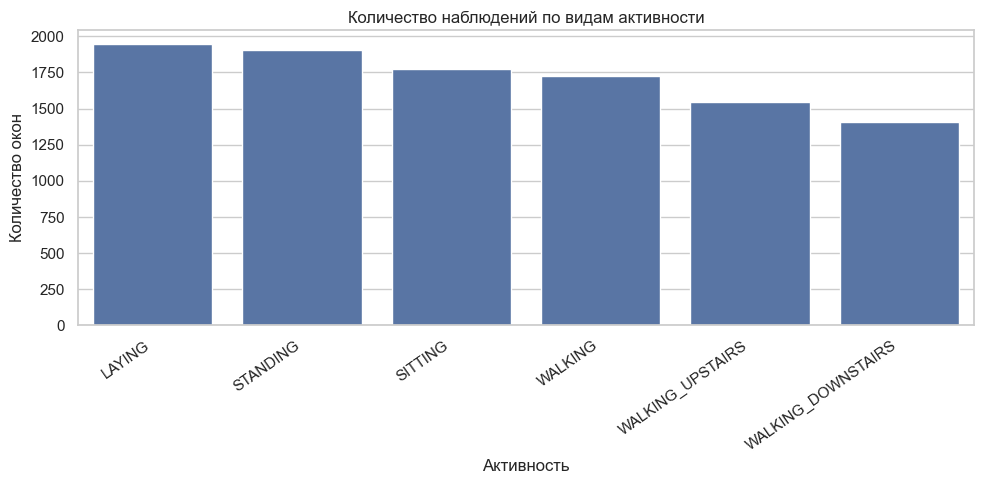

In [8]:
activity_counts = features_df["activity_name"].value_counts().rename_axis("activity").reset_index(name="count")
display(activity_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=activity_counts, x="activity", y="count")
plt.title("Количество наблюдений по видам активности")
plt.xlabel("Активность")
plt.ylabel("Количество окон")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


**Промежуточный вывод.** Если классы распределены примерно равномерно, значит, дальнейшие сравнения по активностям можно делать без сильного перекоса в одну категорию.


activity_name,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
subject,,,,,,
1,50,47,53,95,49,53
2,48,46,54,59,47,48
3,62,52,61,58,49,59
4,54,50,56,60,45,52
5,52,44,56,56,47,47


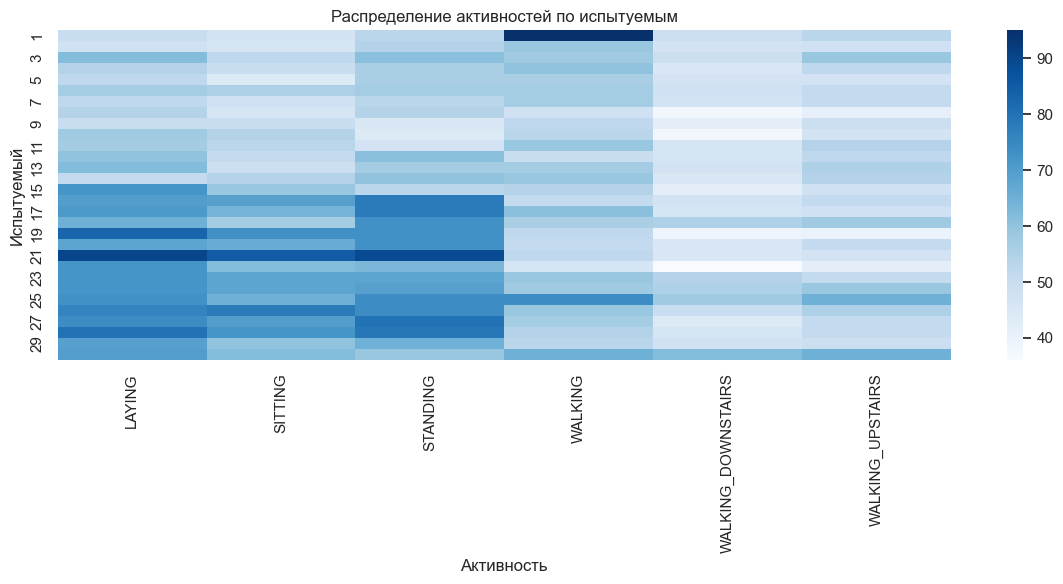

In [9]:
subject_activity = pd.crosstab(features_df["subject"], features_df["activity_name"])
display(subject_activity.head())

plt.figure(figsize=(12, 6))
sns.heatmap(subject_activity, cmap="Blues")
plt.title("Распределение активностей по испытуемым")
plt.xlabel("Активность")
plt.ylabel("Испытуемый")
plt.tight_layout()
plt.show()


## 4. Анализ инженерных признаков

Посмотрим на готовые признаки, которые уже рассчитаны по временным окнам. Для наглядности возьмём несколько признаков, связанных со средним и стандартным отклонением ускорения.


In [10]:
selected_columns = [
    "tBodyAcc-mean()-X",
    "tBodyAcc-mean()-Y",
    "tBodyAcc-mean()-Z",
    "tBodyAcc-std()-X",
    "tBodyAcc-std()-Y",
    "tBodyAcc-std()-Z",
    "tBodyGyro-mean()-X",
    "tBodyGyro-std()-X"
]
selected_columns = [col for col in selected_columns if col in features_df.columns]

summary_by_activity = features_df.groupby("activity_name")[selected_columns].agg(["mean", "std", "median"])
display(summary_by_activity)


tBodyAcc-mean()-X                     tBodyAcc-mean()-Y                     tBodyAcc-mean()-Z  \
                                mean       std    median              mean       std    median              mean   
activity_name                                                                                                      
LAYING                      0.268649  0.096297  0.276812         -0.018318  0.063384 -0.017282         -0.107436   
SITTING                     0.273060  0.041344  0.277284         -0.012690  0.030988 -0.016270         -0.105517   
STANDING                    0.279153  0.019215  0.277544         -0.016152  0.019040 -0.017121         -0.106587   
WALKING                     0.276337  0.049458  0.274655         -0.017907  0.020548 -0.017834         -0.108882   
WALKING_DOWNSTAIRS          0.288137  0.091002  0.284974         -0.016312  0.026592 -0.017741         -0.105762   
WALKING_UPSTAIRS            0.262295  0.075895  0.266150         -0.025923  0.037035 -0.022222         -0.120538   

                                       tBodyAcc-std()-X                     tBodyAcc-std()-Y                      \
                         std    median             mean       std    median             mean       std    median   
activity_name                                                                                                      
LAYING              0.077714 -0.108146        -0.960932  0.077434 -0.982116        -0.943507  0.131616 -0.980270   
SITTING             0.046428 -0.107769        -0.983446  0.032295 -0.993489        -0.934881  0.130136 -0.977582   
STANDING            0.037772 -0.108748        -0.984435  0.023819 -0.993639        -0.932509  0.084004 -0.963231   
WALKING             0.031794 -0.110524        -0.314644  0.142864 -0.329645        -0.023583  0.200104 -0.059982   
WALKING_DOWNSTAIRS  0.049679 -0.108706         0.100766  0.224342  0.110226         0.059549  0.270187  0.028743   
WALKING_UPSTAIRS    0.058149 -0.113988        -0.237990  0.145918 -0.256048        -0.016033  0.199947 -0.038298   

                   tBodyAcc-std()-Z                     tBodyGyro-mean()-X                     tBodyGyro-std()-X  \
                               mean       std    median               mean       std    median              mean   
activity_name                                                                                                      
LAYING                    -0.948069  0.120370 -0.982289          -0.016725  0.055419 -0.027573         -0.967892   
SITTING                   -0.938982  0.119690 -0.975275          -0.038431  0.044972 -0.027760         -0.981022   
STANDING                  -0.939914  0.089640 -0.970970          -0.026687  0.030108 -0.027606         -0.945528   
WALKING                   -0.273921  0.210863 -0.301689          -0.034728  0.130639 -0.029235         -0.469915   
WALKING_DOWNSTAIRS        -0.190805  0.253059 -0.248090          -0.084035  0.323231 -0.102376         -0.333817   
WALKING_UPSTAIRS          -0.175450  0.238208 -0.224946           0.006824  0.313247  0.040329         -0.467607   

                                        
                         std    median  
activity_name                           
LAYING              0.062630 -0.986029  
SITTING             0.036319 -0.992314  
STANDING            0.070341 -0.973397  
WALKING             0.159704 -0.499135  
WALKING_DOWNSTAIRS  0.226720 -0.352941  
WALKING_UPSTAIRS    0.169765 -0.482559

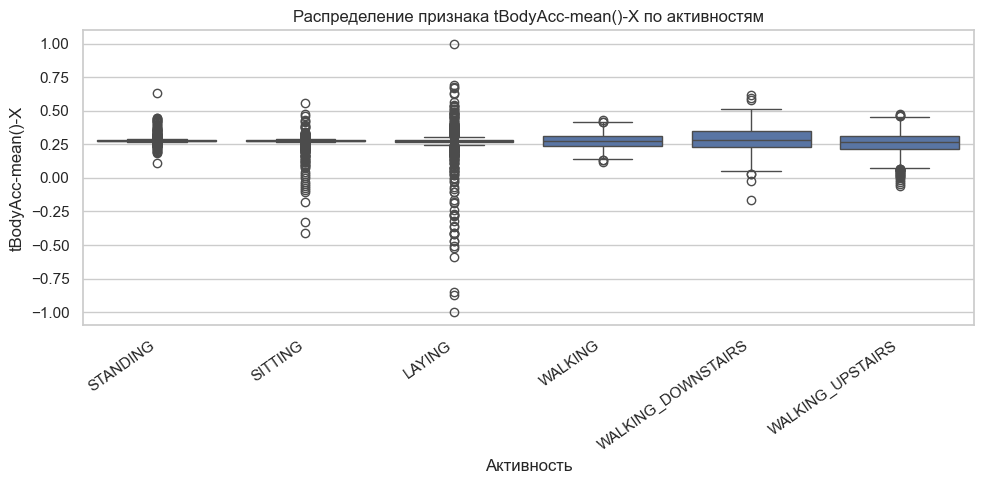

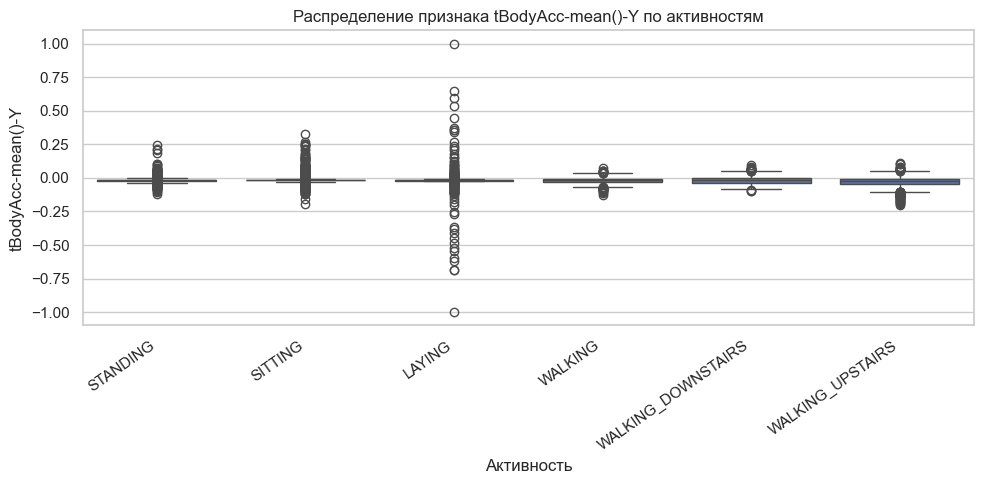

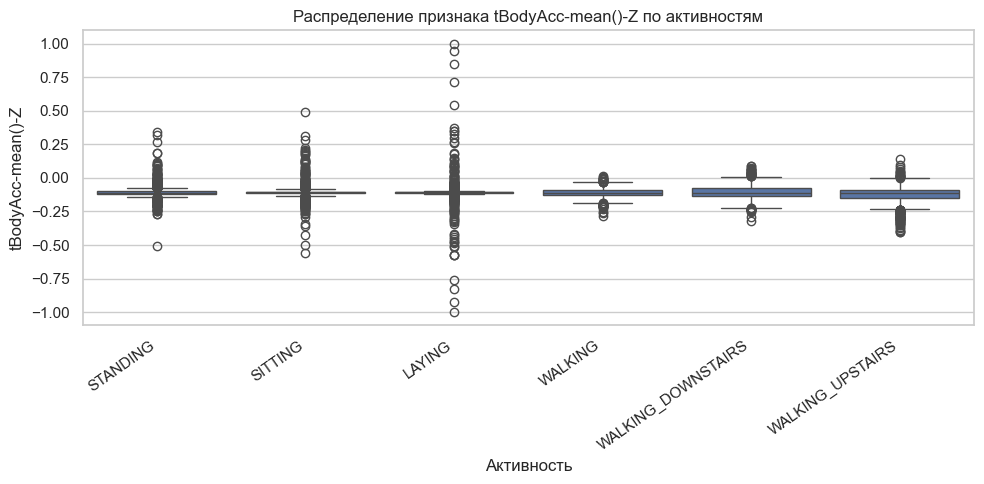

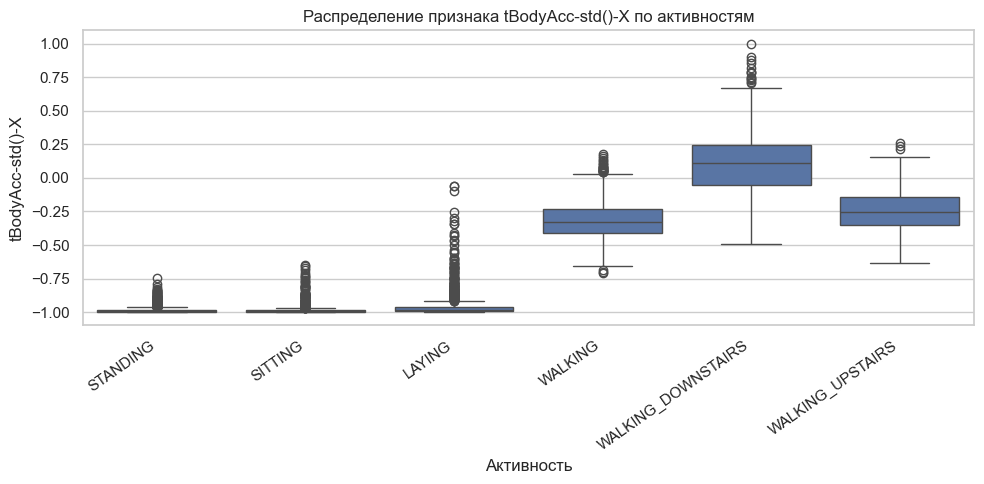

In [11]:
for col in selected_columns[:4]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=features_df, x="activity_name", y=col)
    plt.title(f"Распределение признака {col} по активностям")
    plt.xlabel("Активность")
    plt.ylabel(col)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


## 5. PCA-визуализация

Сожмём 561 числовой признак до двух главных компонент. Это не модель классификации, а способ визуально проверить, разделяются ли активности в пространстве признаков.


Доля объяснённой дисперсии двумя компонентами: [0.5074 0.0624]


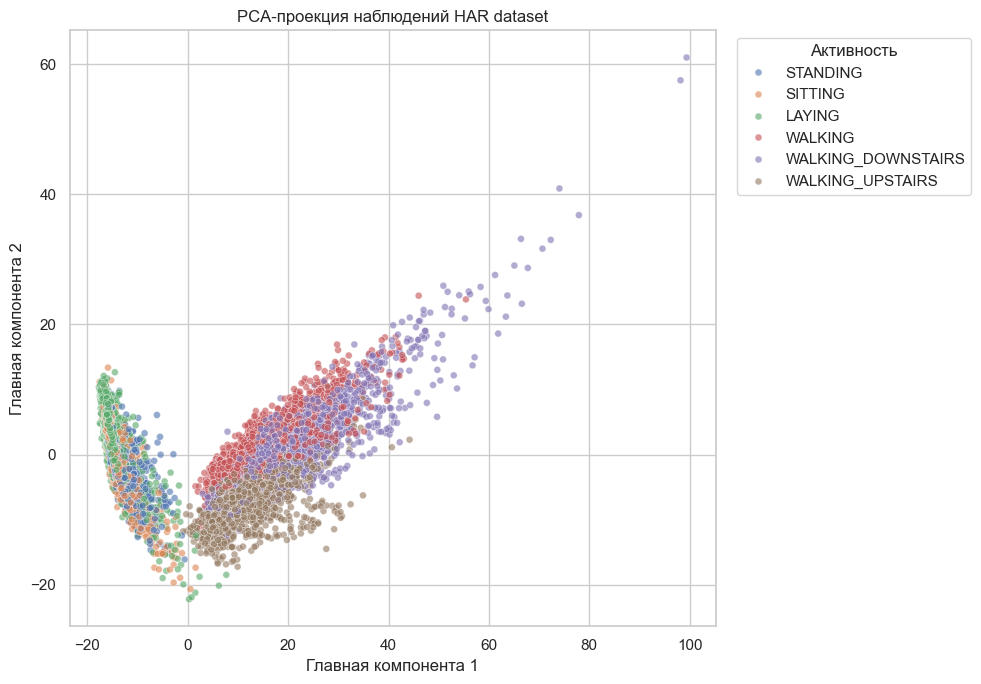

In [12]:
num_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col not in ["activity_id", "subject"]]

sample_df = features_df.copy()
X_scaled = StandardScaler().fit_transform(sample_df[num_cols])

pca = PCA(n_components=2, random_state=42)
pca_values = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1],
    "activity_name": sample_df["activity_name"].values,
    "split": sample_df["split"].values
})

print("Доля объяснённой дисперсии двумя компонентами:", pca.explained_variance_ratio_.round(4))

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="activity_name", alpha=0.6, s=25)
plt.title("PCA-проекция наблюдений HAR dataset")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.legend(title="Активность", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6. Загрузка исходных временных рядов

Теперь переходим к TSA: анализируем не готовые признаки, а сами сигналы из папки `Inertial Signals`.

Каждое наблюдение — это окно из 128 измерений. Частота дискретизации в UCI HAR Dataset — 50 Гц, поэтому одно окно соответствует примерно 2.56 секунды.


In [13]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]


def signal_file_name(signal_name, split):
    return f"{signal_name}_{split}.txt"


def load_signal_matrix(split, signal_name):
    path = datadir / split / "Inertial Signals" / signal_file_name(signal_name, split)
    return pd.read_csv(path, sep=r"\s+", header=None).values


def load_inertial_split(split):
    arrays = [load_signal_matrix(split, signal_name) for signal_name in SIGNAL_NAMES]
    return np.stack(arrays, axis=2)


X_train_raw = load_inertial_split("train")
X_test_raw = load_inertial_split("test")
y_train = train_features["activity_id"].values
subject_train = train_features["subject"].values

print("X_train_raw shape:", X_train_raw.shape, "= наблюдения x время x сигнал")
print("X_test_raw shape:", X_test_raw.shape)


X_train_raw shape: (7352, 128, 9) = наблюдения x время x сигнал
X_test_raw shape: (2947, 128, 9)


In [14]:
def observation_to_df(X_raw, y, obs_index, fs=50):
    signal_df = pd.DataFrame(X_raw[obs_index], columns=SIGNAL_NAMES)
    signal_df["time_sec"] = np.arange(signal_df.shape[0]) / fs
    signal_df["activity_id"] = int(y[obs_index])
    signal_df["activity_name"] = activity_map[int(y[obs_index])]
    signal_df["obs_index"] = obs_index
    return signal_df


example_indices = (
    pd.DataFrame({"activity_id": y_train})
    .reset_index()
    .groupby("activity_id")["index"]
    .first()
    .tolist()
)

example_indices


[78, 150, 125, 27, 0, 51]

## 7. Визуализация временных рядов

Для начала посмотрим, как отличаются сигналы акселерометра и гироскопа для разных типов активности.


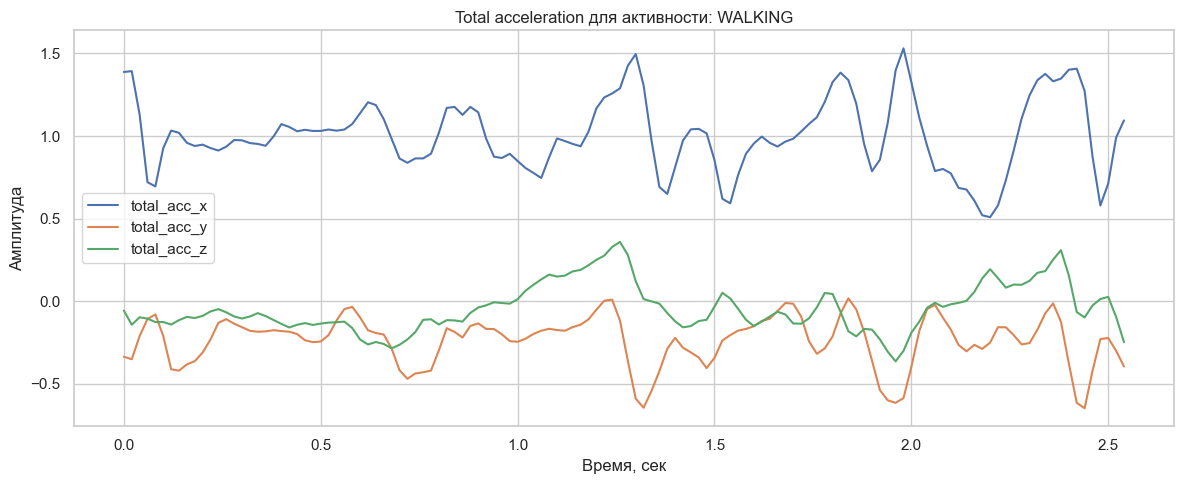

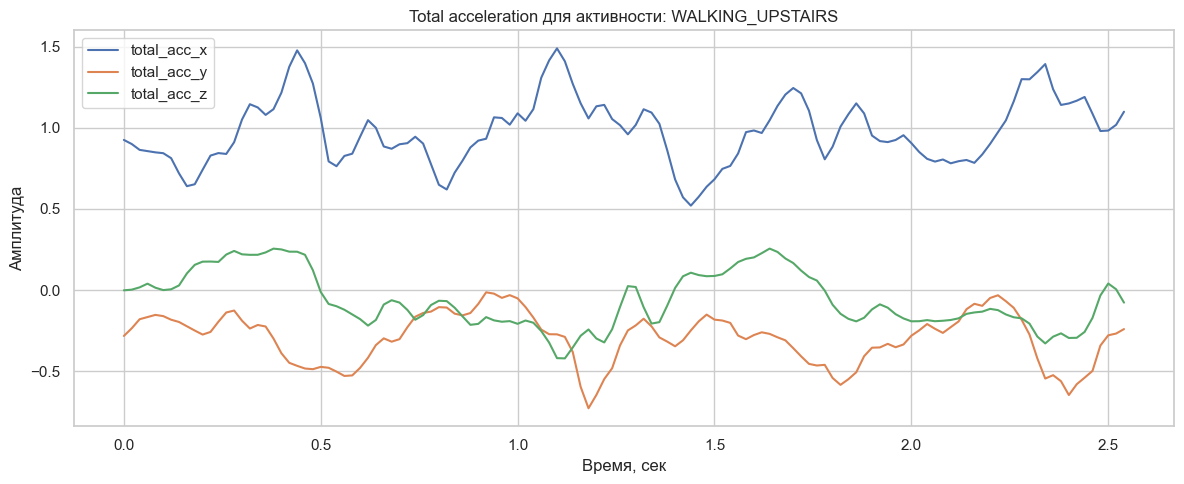

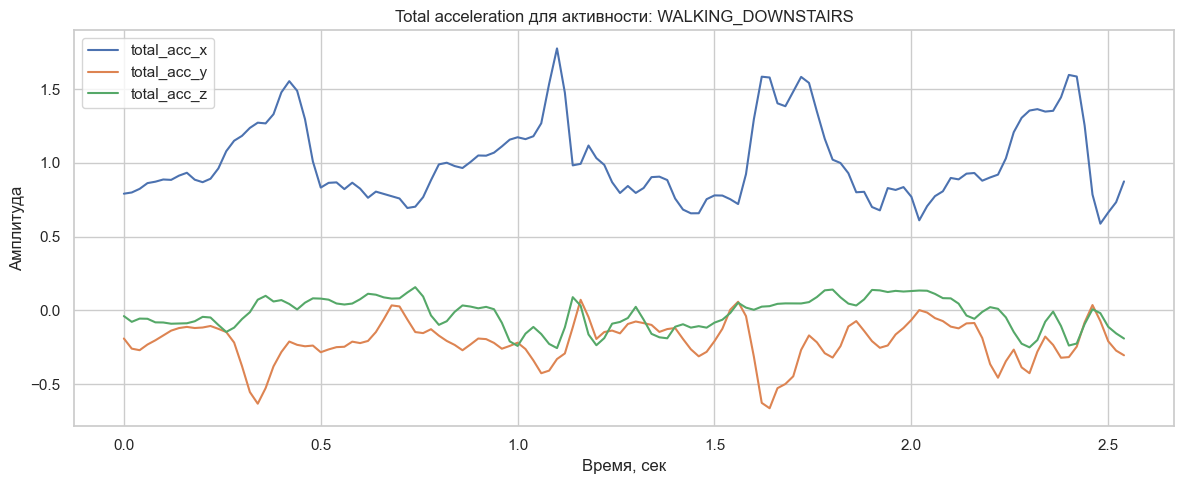

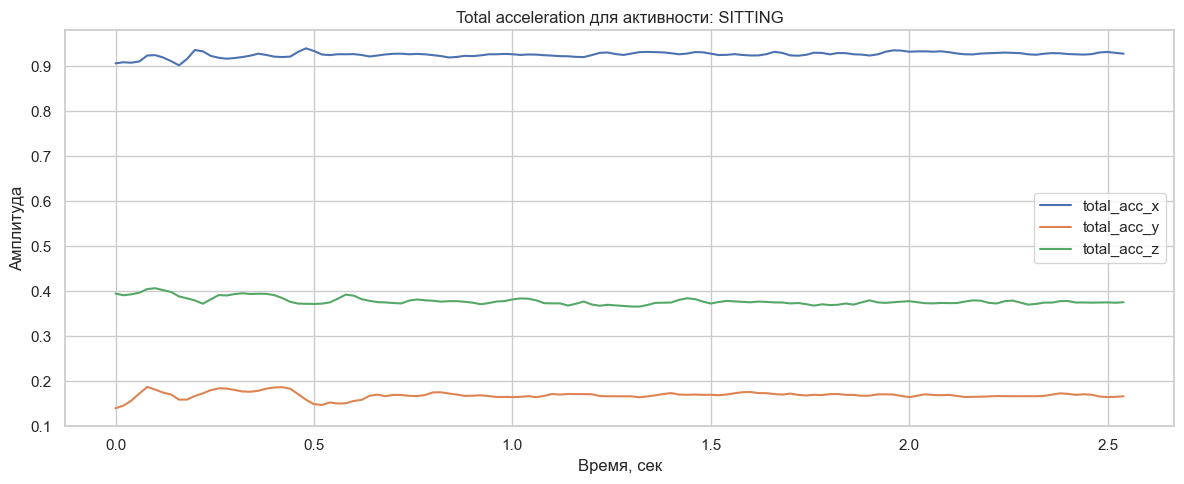

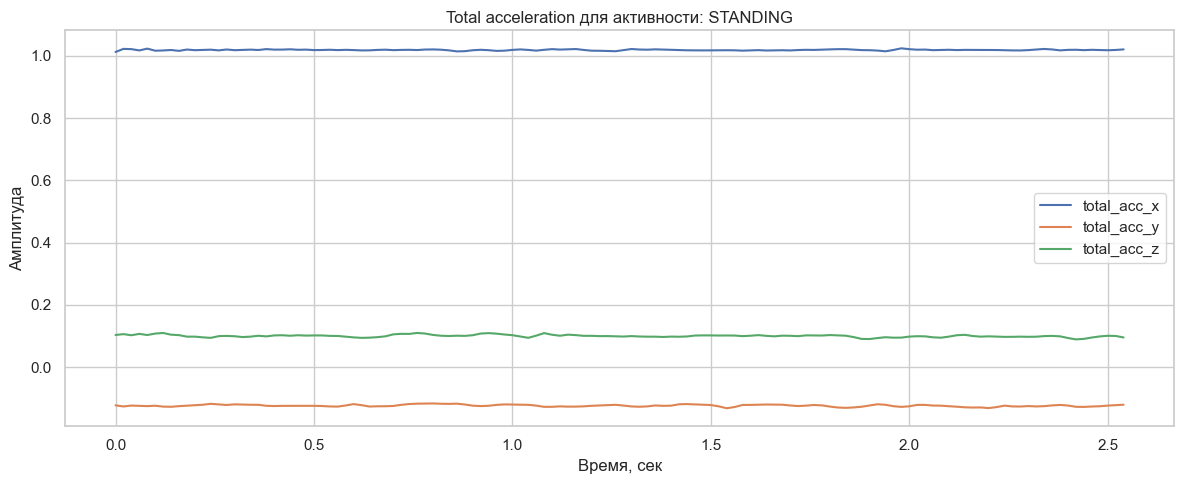

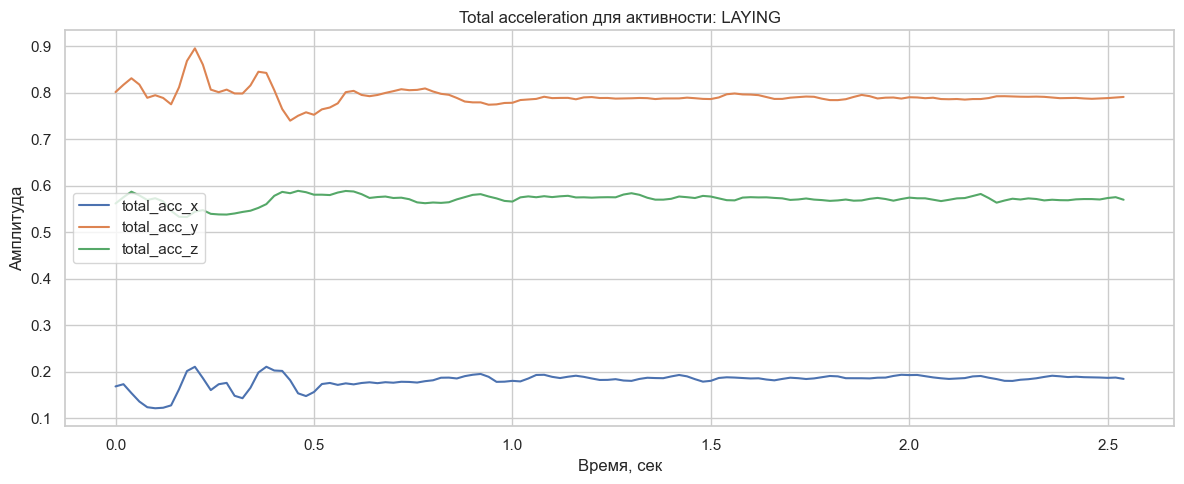

In [15]:
for obs_index in example_indices:
    signal_df = observation_to_df(X_train_raw, y_train, obs_index)
    activity_name = signal_df["activity_name"].iloc[0]

    plt.figure(figsize=(12, 5))
    plt.plot(signal_df["time_sec"], signal_df["total_acc_x"], label="total_acc_x")
    plt.plot(signal_df["time_sec"], signal_df["total_acc_y"], label="total_acc_y")
    plt.plot(signal_df["time_sec"], signal_df["total_acc_z"], label="total_acc_z")
    plt.title(f"Total acceleration для активности: {activity_name}")
    plt.xlabel("Время, сек")
    plt.ylabel("Амплитуда")
    plt.legend()
    plt.tight_layout()
    plt.show()


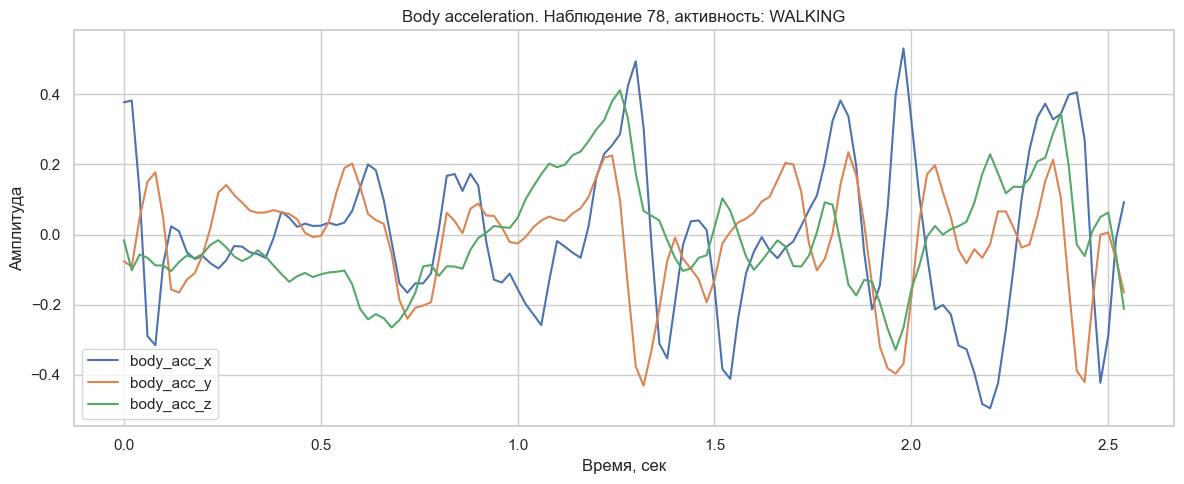

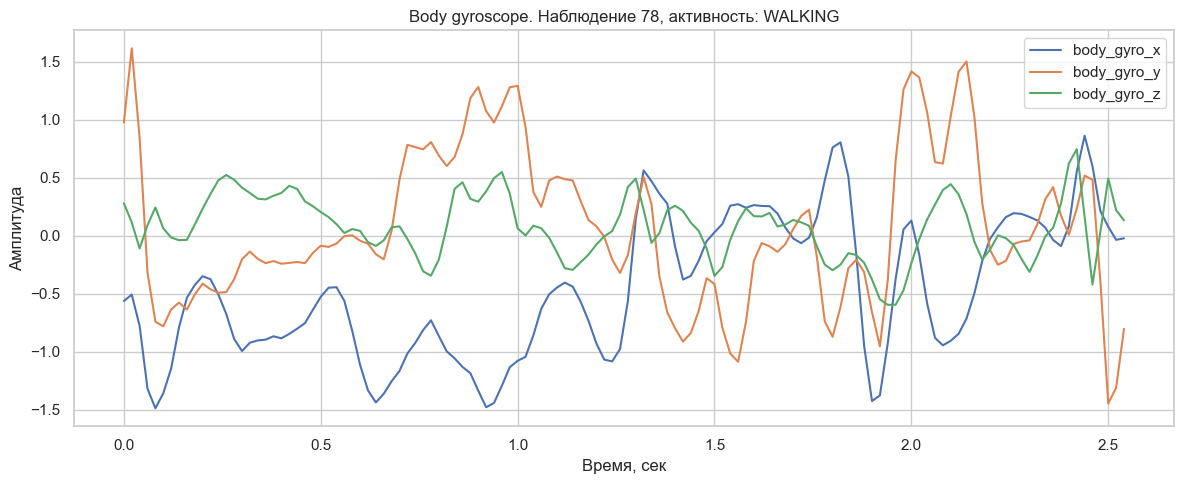

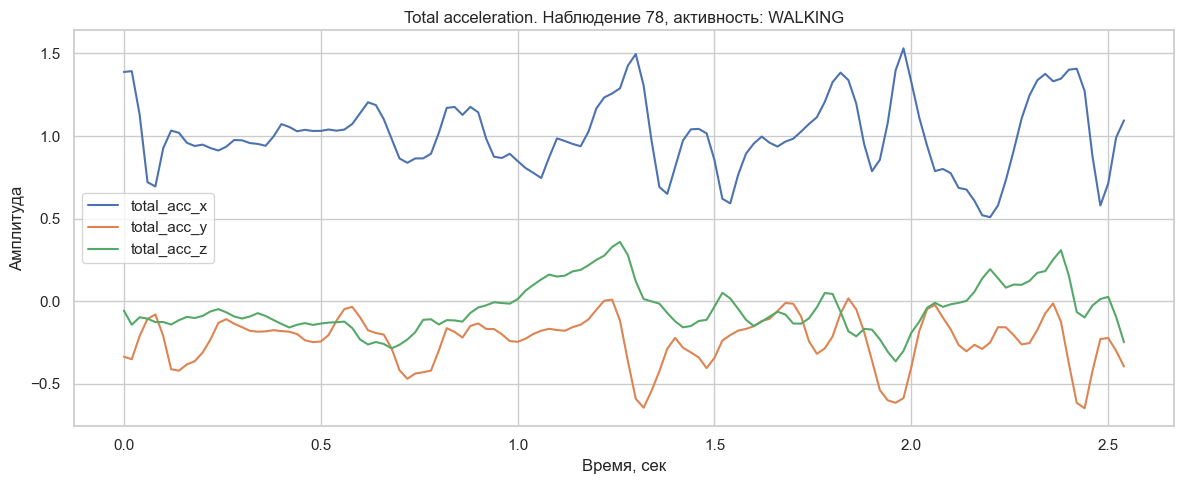

In [16]:
selected_obs = example_indices[0]
selected_signal_df = observation_to_df(X_train_raw, y_train, selected_obs)
selected_activity = selected_signal_df["activity_name"].iloc[0]

signal_groups = {
    "Body acceleration": ["body_acc_x", "body_acc_y", "body_acc_z"],
    "Body gyroscope": ["body_gyro_x", "body_gyro_y", "body_gyro_z"],
    "Total acceleration": ["total_acc_x", "total_acc_y", "total_acc_z"]
}

for group_name, cols in signal_groups.items():
    plt.figure(figsize=(12, 5))
    for col in cols:
        plt.plot(selected_signal_df["time_sec"], selected_signal_df[col], label=col)
    plt.title(f"{group_name}. Наблюдение {selected_obs}, активность: {selected_activity}")
    plt.xlabel("Время, сек")
    plt.ylabel("Амплитуда")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Расчёт статистических признаков по окнам

Для каждого окна временного ряда посчитаем простые статистики: среднее, стандартное отклонение, минимум, максимум, медиану, межквартильный размах и энергию сигнала.

Такие признаки часто используются как базовый этап обработки временных рядов с датчиков.


In [17]:
def iqr(values):
    return np.percentile(values, 75) - np.percentile(values, 25)


def build_window_stats(X_raw, y, subjects, split):
    rows = []
    for obs_idx in range(X_raw.shape[0]):
        row = {
            "obs_index": obs_idx,
            "activity_id": int(y[obs_idx]),
            "activity_name": activity_map[int(y[obs_idx])],
            "subject": int(subjects[obs_idx]),
            "split": split
        }
        for signal_idx, signal_name in enumerate(SIGNAL_NAMES):
            values = X_raw[obs_idx, :, signal_idx]
            row[f"{signal_name}_mean"] = float(np.mean(values))
            row[f"{signal_name}_std"] = float(np.std(values))
            row[f"{signal_name}_min"] = float(np.min(values))
            row[f"{signal_name}_max"] = float(np.max(values))
            row[f"{signal_name}_median"] = float(np.median(values))
            row[f"{signal_name}_iqr"] = float(iqr(values))
            row[f"{signal_name}_energy"] = float(np.sum(values ** 2) / len(values))
        rows.append(row)
    return pd.DataFrame(rows)


stats_df = build_window_stats(X_train_raw, y_train, subject_train, "train")
print("Размер таблицы статистических признаков:", stats_df.shape)
display(stats_df.head())


Размер таблицы статистических признаков: (7352, 68)


,obs_index,activity_id,activity_name,subject,split,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_iqr,body_acc_x_energy,body_acc_y_mean,body_acc_y_std,body_acc_y_min,body_acc_y_max,body_acc_y_median,body_acc_y_iqr,body_acc_y_energy,body_acc_z_mean,body_acc_z_std,body_acc_z_min,body_acc_z_max,body_acc_z_median,body_acc_z_iqr,body_acc_z_energy,body_gyro_x_mean,body_gyro_x_std,body_gyro_x_min,body_gyro_x_max,body_gyro_x_median,body_gyro_x_iqr,body_gyro_x_energy,body_gyro_y_mean,body_gyro_y_std,body_gyro_y_min,body_gyro_y_max,body_gyro_y_median,body_gyro_y_iqr,body_gyro_y_energy,body_gyro_z_mean,body_gyro_z_std,body_gyro_z_min,body_gyro_z_max,body_gyro_z_median,body_gyro_z_iqr,body_gyro_z_energy,total_acc_x_mean,total_acc_x_std,total_acc_x_min,total_acc_x_max,total_acc_x_median,total_acc_x_iqr,total_acc_x_energy,total_acc_y_mean,total_acc_y_std,total_acc_y_min,total_acc_y_max,total_acc_y_median,total_acc_y_iqr,total_acc_y_energy,total_acc_z_mean,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_iqr,total_acc_z_energy
0,0,5,STANDING,1,train,0.002269,0.002941,-0.004294,0.010810,0.002025,0.004812,0.000014,-0.001655,0.004601,-0.012610,0.010767,-0.001827,0.005288,0.000024,-0.008126,0.018504,-0.033006,0.055561,-0.012744,0.017835,0.000408,0.022250,0.014434,-0.003862,0.050545,0.018057,0.021992,0.000703,0.019403,0.019828,-0.009022,0.074850,0.014191,0.026714,0.000770,0.009468,0.005943,-0.006891,0.022859,0.008921,0.008300,0.000125,1.019305,0.001791,1.012817,1.024606,1.019335,0.002154,1.038985,-0.124262,0.003270,-0.132631,-0.117210,-0.124302,0.005065,0.015452,0.099732,0.003970,0.088742,0.109485,0.099841,0.004066,0.009962
1,1,5,STANDING,1,train,0.000174,0.001981,-0.006706,0.005251,0.000110,0.001970,0.000004,0.000382,0.005930,-0.012610,0.016634,-0.000319,0.008145,0.000035,-0.005025,0.010122,-0.026860,0.012660,-0.003938,0.016466,0.000128,0.011926,0.016334,-0.038650,0.055249,0.011763,0.010833,0.000409,-0.004314,0.010356,-0.030160,0.016858,-0.003985,0.014572,0.000126,0.006308,0.007431,-0.009759,0.025133,0.006498,0.010422,0.000095,1.019448,0.001932,1.012893,1.024606,1.019366,0.002227,1.039278,-0.122936,0.004930,-0.132631,-0.108560,-0.123188,0.006164,0.015137,0.096939,0.004918,0.081100,0.105788,0.097748,0.005657,0.009421
2,2,5,STANDING,1,train,0.000428,0.002908,-0.010483,0.008167,0.000627,0.003138,0.000009,-0.001222,0.007310,-0.015333,0.016634,-0.002159,0.012134,0.000055,-0.001703,0.006786,-0.014596,0.012660,-0.001551,0.009852,0.000049,-0.004150,0.022256,-0.038650,0.055249,-0.007544,0.036608,0.000513,-0.012640,0.006920,-0.037503,0.000761,-0.010961,0.007812,0.000208,0.004335,0.008753,-0.009759,0.028609,0.002467,0.013243,0.000095,1.019927,0.002904,1.009013,1.027664,1.020132,0.003096,1.040259,-0.124997,0.006460,-0.137142,-0.108560,-0.125918,0.010128,0.015666,0.092897,0.006145,0.081100,0.105788,0.093636,0.008947,0.008668
3,3,5,STANDING,1,train,0.000329,0.002678,-0.010483,0.008167,0.000269,0.003128,0.000007,-0.004753,0.004551,-0.015333,0.005359,-0.005010,0.006488,0.000043,-0.004947,0.004684,-0.015679,0.006107,-0.004365,0.007124,0.000046,-0.016228,0.009165,-0.037516,0.010361,-0.016846,0.013132,0.000347,-0.007697,0.007793,-0.037503,0.007778,-0.007601,0.009072,0.000120,-0.000352,0.008186,-0.013223,0.028609,-0.001816,0.006907,0.000067,1.020349,0.002574,1.009013,1.027664,1.020465,0.002786,1.041119,-0.130493,0.004029,-0.143545,-0.116749,-0.130720,0.004376,0.017045,0.087654,0.004945,0.076888,0.098737,0.087501,0.007824,0.007708
4,4,5,STANDING,1,train,-0.000195,0.002015,-0.006847,0.005650,-0.000144,0.002622,0.000004,0.000298,0.004991,-0.014662,0.009661,0.000389,0.007183,0.000025,-0.002330,0.004719,-0.015679,0.009009,-0.001668,0.005732,0.000028,-0.006483,0.014544,-0.024902,0.043706,-0.010315,0.014639,0.000254,-0.000166,0.007815,-0.020582,0.017447,-0.001748,0.009967,0.000061,-0.003957,0.008260,-0.021141,0.019890,-0.003654,0.009755,0.000084,1.020255,0.001949,1.013645,1.026194,1.020201,0.002506,1

,body_acc_x_energy,body_acc_y_energy,body_acc_z_energy,body_gyro_x_energy,body_gyro_y_energy,body_gyro_z_energy,total_acc_x_energy,total_acc_y_energy,total_acc_z_energy
activity_name,,,,,,,,,
LAYING,0.0013,0.0023,0.0017,0.0086,0.0037,0.0058,0.0251,0.5229,0.4672
SITTING,0.0002,0.0009,0.0008,0.0037,0.0040,0.0047,0.9149,0.0558,0.0721
STANDING,0.0001,0.0004,0.0006,0.0057,0.0030,0.0015,1.0035,0.0369,0.0263
WALKING,0.0524,0.0294,0.0207,0.2561,0.3079,0.1157,1.0441,0.0687,0.0503
WALKING_DOWNSTAIRS,0.1427,0.0363,0.0256,0.5093,0.3302,0.1430,1.1260,0.0657,0.0537
WALKING_UPSTAIRS,0.0670,0.0311,0.0272,0.3503,0.3303,0.1695,0.9703,0.1144,0.0888


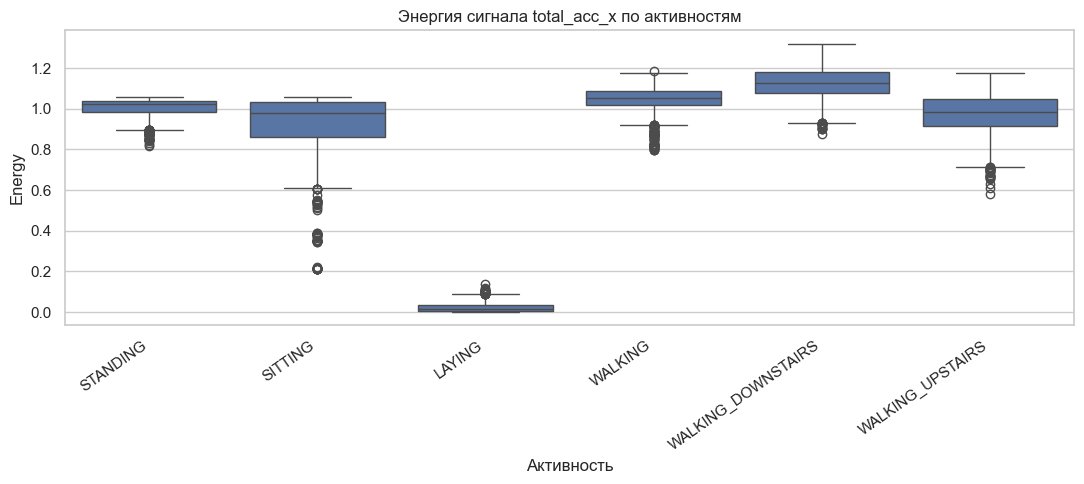

In [18]:
energy_cols = [col for col in stats_df.columns if col.endswith("_energy")]
energy_summary = stats_df.groupby("activity_name")[energy_cols].mean().round(4)
display(energy_summary)

plt.figure(figsize=(11, 5))
sns.boxplot(data=stats_df, x="activity_name", y="total_acc_x_energy")
plt.title("Энергия сигнала total_acc_x по активностям")
plt.xlabel("Активность")
plt.ylabel("Energy")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


**Промежуточный вывод.** Динамические активности обычно дают более высокую энергию и разброс сигнала, а статические активности — более спокойные временные ряды. Это хорошо видно на статистиках по окнам.


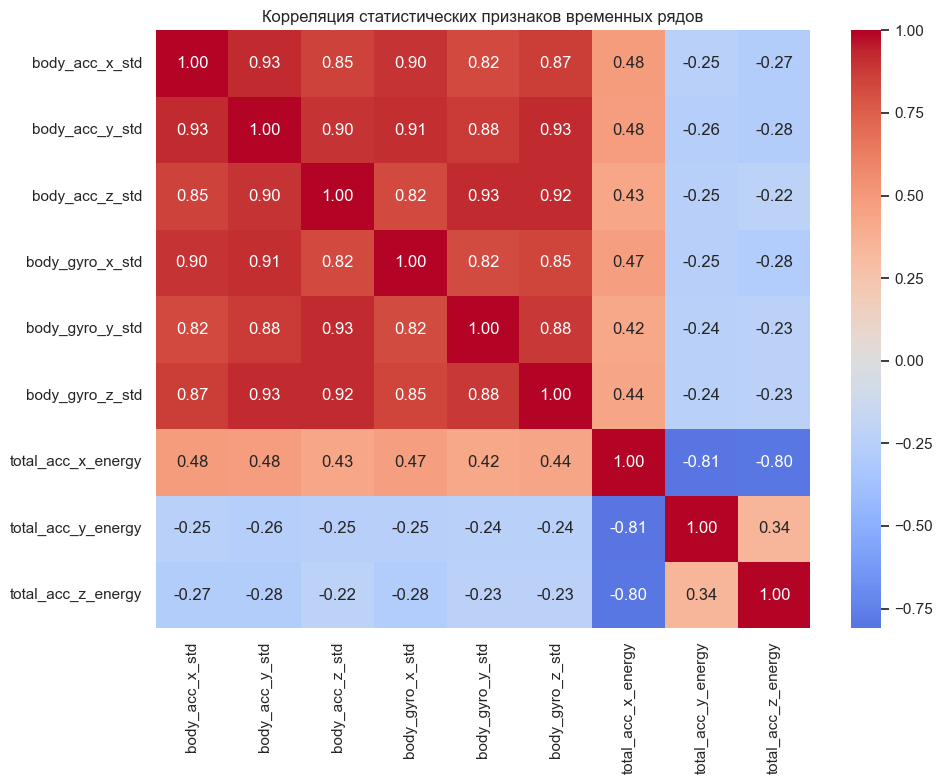

In [19]:
corr_cols = [
    "body_acc_x_std", "body_acc_y_std", "body_acc_z_std",
    "body_gyro_x_std", "body_gyro_y_std", "body_gyro_z_std",
    "total_acc_x_energy", "total_acc_y_energy", "total_acc_z_energy"
]

plt.figure(figsize=(10, 8))
sns.heatmap(stats_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция статистических признаков временных рядов")
plt.tight_layout()
plt.show()


## 9. TSA: скользящее среднее и разброс

Выберем один сигнал и посмотрим его сглаженную динамику. Скользящее среднее помогает увидеть локальный тренд внутри короткого окна наблюдения.


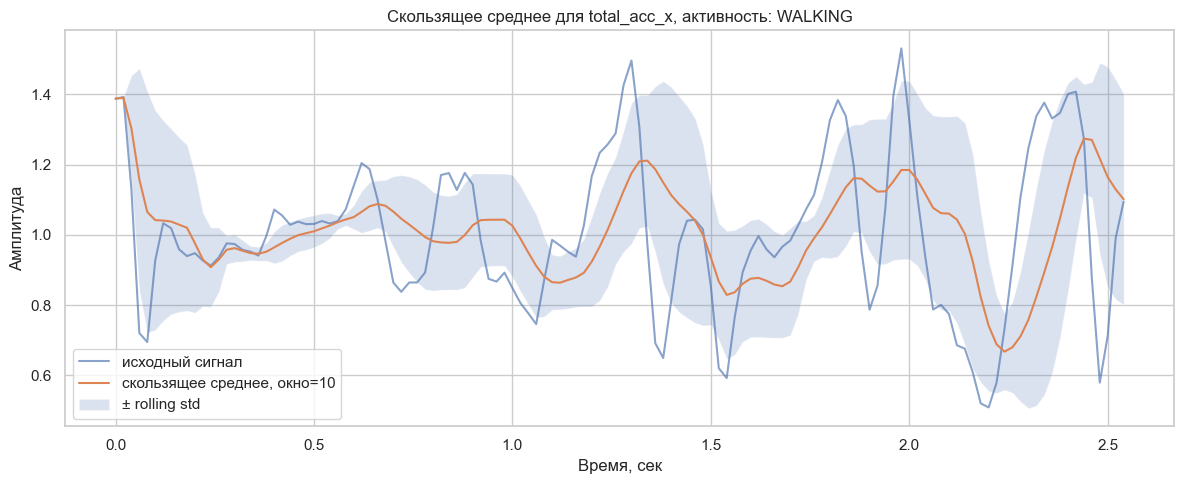

In [20]:
fs = 50
signal_name = "total_acc_x"
signal_idx = SIGNAL_NAMES.index(signal_name)
series = pd.Series(X_train_raw[selected_obs, :, signal_idx], name=signal_name)
time_sec = np.arange(len(series)) / fs

rolling_mean = series.rolling(window=10, min_periods=1).mean()
rolling_std = series.rolling(window=10, min_periods=1).std().fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(time_sec, series, label="исходный сигнал", alpha=0.65)
plt.plot(time_sec, rolling_mean, label="скользящее среднее, окно=10")
plt.fill_between(time_sec, rolling_mean - rolling_std, rolling_mean + rolling_std, alpha=0.2, label="± rolling std")
plt.title(f"Скользящее среднее для {signal_name}, активность: {selected_activity}")
plt.xlabel("Время, сек")
plt.ylabel("Амплитуда")
plt.legend()
plt.tight_layout()
plt.show()


## 10. TSA: автокорреляция и частичная автокорреляция

ACF показывает связь ряда с его лаговыми значениями. PACF показывает связь с лагом после исключения влияния промежуточных лагов.


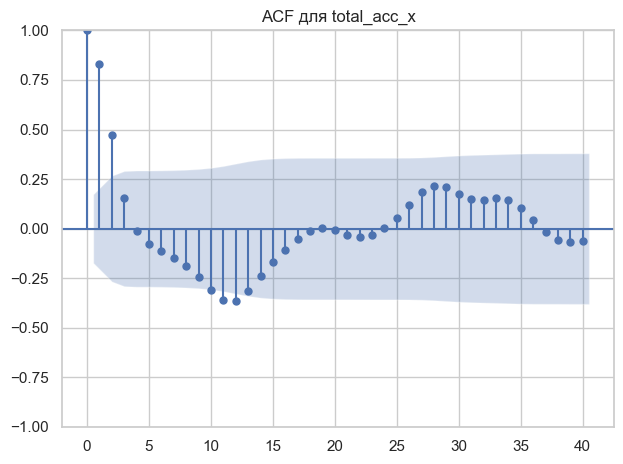

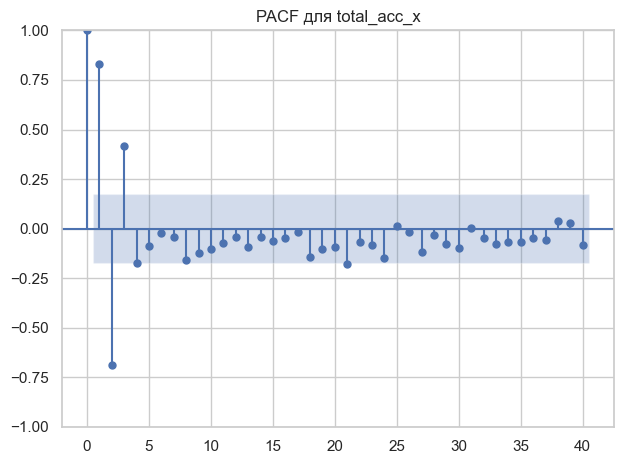

In [21]:
plot_acf(series, lags=40)
plt.title(f"ACF для {signal_name}")
plt.tight_layout()
plt.show()

plot_pacf(series, lags=40, method="ywm")
plt.title(f"PACF для {signal_name}")
plt.tight_layout()
plt.show()


In [22]:
ljung_result = acorr_ljungbox(series, lags=[10, 20], return_df=True)
display(ljung_result)

print("Если p-value маленькое, то ряд не похож на белый шум: в нём есть автокорреляционная структура.")


,lb_stat,lb_pvalue
10,154.673581,4.065764e-28
20,221.199074,6.882387e-36


Если p-value маленькое, то ряд не похож на белый шум: в нём есть автокорреляционная структура.


## 11. TSA: проверка стационарности

Используем ADF-тест. Нулевая гипотеза ADF: ряд имеет единичный корень, то есть является нестационарным.


In [23]:
def adf_report(values):
    result = adfuller(values)
    report = pd.DataFrame({
        "metric": ["ADF statistic", "p-value", "used_lags", "n_obs"],
        "value": [result[0], result[1], result[2], result[3]]
    })
    critical = pd.DataFrame({
        "level": list(result[4].keys()),
        "critical_value": list(result[4].values())
    })
    return report, critical


adf_main, adf_critical = adf_report(series)
display(adf_main)
display(adf_critical)

p_value = float(adf_main.loc[adf_main["metric"] == "p-value", "value"].iloc[0])
if p_value < 0.05:
    print("Вывод: p-value < 0.05, ряд можно считать стационарным на 5% уровне значимости.")
else:
    print("Вывод: p-value >= 0.05, нет оснований уверенно считать ряд стационарным.")


,metric,value
0,ADF statistic,-5.039512
1,p-value,0.000019
2,used_lags,13.000000
3,n_obs,114.000000


,level,critical_value
0,1%,-3.489058
1,5%,-2.887246
2,10%,-2.580481


Вывод: p-value < 0.05, ряд можно считать стационарным на 5% уровне значимости.


## 12. TSA: частотный анализ через FFT

Быстрое преобразование Фурье позволяет посмотреть, какие частоты сильнее всего выражены в сигнале.


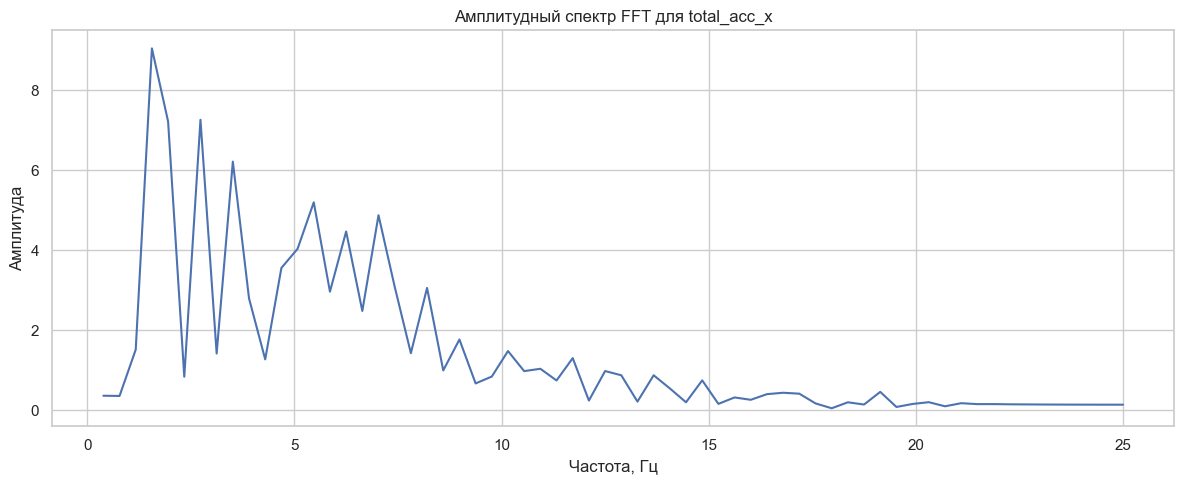

Доминирующая частота: 1.562 Гц


In [24]:
centered = series.values - series.values.mean()
yf = np.abs(rfft(centered))
xf = rfftfreq(len(centered), 1 / fs)

non_zero = xf > 0
dominant_frequency = xf[non_zero][np.argmax(yf[non_zero])]

plt.figure(figsize=(12, 5))
plt.plot(xf[non_zero], yf[non_zero])
plt.title(f"Амплитудный спектр FFT для {signal_name}")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.tight_layout()
plt.show()

print(f"Доминирующая частота: {dominant_frequency:.3f} Гц")


## 13. Мини-пример прогнозирования одного сигнала

Для полноты TSA попробуем построить простую SARIMAX/ARMA-модель на одном коротком сигнале. Это не промышленный прогноз, а демонстрация подхода к моделированию временного ряда.


In [25]:
train_size = 96
train_series = series.iloc[:train_size]
test_series = series.iloc[train_size:]

try:
    model = SARIMAX(
        train_series,
        order=(2, 0, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(test_series))

    rmse = mean_squared_error(test_series, forecast, squared=False)
    r2 = r2_score(test_series, forecast)

    plt.figure(figsize=(12, 5))
    plt.plot(time_sec[:train_size], train_series, label="train")
    plt.plot(time_sec[train_size:], test_series, label="test")
    plt.plot(time_sec[train_size:], forecast, label="forecast")
    plt.title(f"Прогноз SARIMAX для {signal_name}")
    plt.xlabel("Время, сек")
    plt.ylabel("Амплитуда")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
except Exception as exc:
    print("SARIMAX не удалось обучить на выбранном коротком ряде:", exc)


SARIMAX не удалось обучить на выбранном коротком ряде: got an unexpected keyword argument 'squared'


## 14. Сохранение подготовленных данных

Сохраним статистические признаки по окнам в CSV. Их можно использовать для дальнейшего моделирования.


In [26]:
stats_df.to_csv("har_window_statistics.csv", index=False)
features_df.to_csv("har_engineered_features.csv", index=False)

print("Файлы сохранены:")
print("- har_window_statistics.csv")
print("- har_engineered_features.csv")


Файлы сохранены:
- har_window_statistics.csv
- har_engineered_features.csv


## Итоговые выводы

1. Данные HAR состоят из нескольких уровней: готовых инженерных признаков и исходных временных рядов акселерометра/гироскопа.
2. Пропусков в загруженной таблице нет, структура данных пригодна для анализа.
3. Классы активности представлены достаточно равномерно, поэтому сравнение активностей не искажается сильным дисбалансом.
4. По boxplot-графикам видно, что признаки ускорения и гироскопа различаются между статическими и динамическими активностями.
5. PCA показывает, что часть активностей визуально отделяется уже в пространстве двух главных компонент, хотя полного разделения двумя компонентами недостаточно.
6. Временные ряды имеют выраженную структуру: скользящее среднее, ACF/PACF и Ljung-Box показывают наличие зависимости между соседними значениями.
7. ADF-тест позволяет формально проверить стационарность выбранного сигнала.
8. FFT помогает выделить доминирующие частоты внутри окна наблюдения.
9. Простая SARIMAX-модель применима как демонстрация прогнозирования, но для HAR-задачи обычно важнее классификация активности, а не долгосрочный прогноз короткого сигнала.

**Общий вывод:** EDA и TSA позволяют понять структуру HAR-датасета, различия между активностями и свойства сенсорных временных рядов до построения ML-моделей.
